In [ ]:
!nvidia-smi

Wed May 20 03:33:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics kaggle -q

from ultralytics import YOLO
import os
import shutil
import zipfile
from pathlib import Path

print("Библиотеки установлены")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Библиотеки установлены


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files

uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle подключен")

Saving kaggle.json to kaggle (1).json
Kaggle подключен


In [ ]:
!kaggle datasets download -d dataclusterlabs/handbag-image-dataset-luggage-dataset
!kaggle datasets download -d dataclusterlabs/suitcaseluggage-dataset

print("Датасеты скачаны")

Dataset URL: https://www.kaggle.com/datasets/dataclusterlabs/handbag-image-dataset-luggage-dataset
License(s): CC0-1.0
handbag-image-dataset-luggage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/dataclusterlabs/suitcaseluggage-dataset
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
suitcaseluggage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Датасеты скачаны


In [ ]:
import zipfile
import os

# создаем папки
os.makedirs("/content/datasets/handbag", exist_ok=True)
os.makedirs("/content/datasets/luggage", exist_ok=True)

# распаковка handbag
with zipfile.ZipFile("/content/handbag-image-dataset-luggage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/datasets/handbag")

# распаковка luggage
with zipfile.ZipFile("/content/suitcaseluggage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/datasets/luggage")

print("Распаковка завершена")

Распаковка завершена


In [ ]:
import os

for root, dirs, files in os.walk("/content/datasets"):
    print(root)
    print("Папок:", len(dirs))
    print("Файлов:", len(files))
    print("-" * 50)

/content/datasets
Папок: 2
Файлов: 0
--------------------------------------------------
/content/datasets/luggage
Папок: 2
Файлов: 0
--------------------------------------------------
/content/datasets/luggage/annotation
Папок: 1
Файлов: 0
--------------------------------------------------
/content/datasets/luggage/annotation/annotation
Папок: 0
Файлов: 148
--------------------------------------------------
/content/datasets/luggage/suitcase
Папок: 1
Файлов: 0
--------------------------------------------------
/content/datasets/luggage/suitcase/suitcase
Папок: 0
Файлов: 148
--------------------------------------------------
/content/datasets/handbag
Папок: 1
Файлов: 0
--------------------------------------------------
/content/datasets/handbag/hand bag 300
Папок: 0
Файлов: 82
--------------------------------------------------


In [ ]:
import os

annotation_path = "/content/datasets/luggage/annotation/annotation"

files = os.listdir(annotation_path)

print("Количество файлов:", len(files))
print("\nПервые 5 файлов:")

for f in files[:5]:
    print(f)

Количество файлов: 148

Первые 5 файлов:
Datacluster_Labs_Suitcase (17).xml
Datacluster_Labs_Suitcase (77).xml
Datacluster_Labs_Suitcase (68).xml
Datacluster_Labs_Suitcase (117).xml
Datacluster_Labs_Suitcase (8).xml


In [ ]:
sample_file = "/content/datasets/luggage/annotation/annotation/" + files[0]

with open(sample_file, "r") as f:
    print(f.read())

<annotation>
  <folder>Datacluster</folder>
  <filename>Datacluster_Labs_Suitcase (17).jpg</filename>
  <source>
    <database>Unknown</database>
    <annotation>Unknown</annotation>
    <image>Unknown</image>
  </source>
  <size>
    <width>2448</width>
    <height>3264</height>
    <depth></depth>
  </size>
  <segmented>0</segmented>
  <object>
    <name>suitcase</name>
    <truncated>0</truncated>
    <occluded>0</occluded>
    <difficult>0</difficult>
    <bndbox>
      <xmin>647.41</xmin>
      <ymin>608.07</ymin>
      <xmax>2077.41</xmax>
      <ymax>1910.5</ymax>
    </bndbox>
    <attributes>
      <attribute>
        <name>rotation</name>
        <value>0.0</value>
      </attribute>
    </attributes>
  </object>
</annotation>



In [ ]:
import os
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path

# пути
images_path = "/content/datasets/luggage/suitcase/suitcase"
annotations_path = "/content/datasets/luggage/annotation/annotation"

# новый датасет YOLO
dataset_path = "/content/yolo_dataset"

train_images = f"{dataset_path}/images/train"
val_images = f"{dataset_path}/images/val"

train_labels = f"{dataset_path}/labels/train"
val_labels = f"{dataset_path}/labels/val"

for path in [train_images, val_images, train_labels, val_labels]:
    os.makedirs(path, exist_ok=True)

images = [f for f in os.listdir(images_path) if f.endswith(".jpg")]

random.shuffle(images)

split_index = int(len(images) * 0.8)

train_files = images[:split_index]
val_files = images[split_index:]

print("Train:", len(train_files))
print("Val:", len(val_files))

Train: 118
Val: 30


In [ ]:
classes = ["bag"]

def convert_xml_to_yolo(xml_file, output_txt):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find("size")

    width = float(size.find("width").text)
    height = float(size.find("height").text)

    with open(output_txt, "w") as f:

        for obj in root.findall("object"):

            class_id = 0
            xmlbox = obj.find("bndbox")

            xmin = float(xmlbox.find("xmin").text)
            xmax = float(xmlbox.find("xmax").text)
            ymin = float(xmlbox.find("ymin").text)
            ymax = float(xmlbox.find("ymax").text)

            x_center = ((xmin + xmax) / 2) / width
            y_center = ((ymin + ymax) / 2) / height

            box_width = (xmax - xmin) / width
            box_height = (ymax - ymin) / height

            f.write(
                f"{class_id} {x_center} {y_center} {box_width} {box_height}\n"
            )

print("Функция исправлена")

Функция исправлена


In [ ]:
def process_files(file_list, images_dir, labels_dir):
    """копи изображения и YOLO разметка"""
    for filename in file_list:
        # копируем изображение
        src_img = os.path.join(images_path, filename)
        dst_img = os.path.join(images_dir, filename)
        shutil.copy(src_img, dst_img)

        # конвертируем XML в YOLO формат
        xml_file = os.path.join(annotations_path, filename.replace(".jpg", ".xml"))
        txt_file = os.path.join(labels_dir, filename.replace(".jpg", ".txt"))

        if os.path.exists(xml_file):
            convert_xml_to_yolo(xml_file, txt_file)
        else:
            print(f"XML файл не найден для {filename}")

In [ ]:
process_files(train_files, train_images, train_labels)
process_files(val_files, val_images, val_labels)

print("YOLO датасет готов")

YOLO датасет готов


In [ ]:
yaml_text = """
path: /content/yolo_dataset

train: images/train
val: images/val

names:
  0: bag
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml создан")

data.yaml создан


In [ ]:
for root, dirs, files in os.walk("/content/yolo_dataset"):
    print(root)
    print("Файлов:", len(files))
    print("-" * 40)

/content/yolo_dataset
Файлов: 1
----------------------------------------
/content/yolo_dataset/labels
Файлов: 2
----------------------------------------
/content/yolo_dataset/labels/val
Файлов: 56
----------------------------------------
/content/yolo_dataset/labels/train
Файлов: 144
----------------------------------------
/content/yolo_dataset/images
Файлов: 0
----------------------------------------
/content/yolo_dataset/images/val
Файлов: 56
----------------------------------------
/content/yolo_dataset/images/train
Файлов: 144
----------------------------------------


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/yolo_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="bag_detector"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bag_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fcb61fc80e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from google.colab import files

uploaded = files.upload()

test_image = list(uploaded.keys())[0]

print("Загружено фото:", test_image)

Saving pngwing.com.png to pngwing.com (1).png
Загружено фото: pngwing.com (1).png


In [ ]:
import os
from pathlib import Path

# поиск всех файлов .pt в папке runs
runs_path = "/content/runs"
pt_files = list(Path(runs_path).rglob("*.pt"))

print("Найденные модели:")
for f in pt_files:
    print(f"  - {f}")
    print(f"    Размер: {f.stat().st_size / 1024 / 1024:.2f} MB")

Найденные модели:
  - /content/runs/detect/bag_detector-2/weights/best.pt
    Размер: 5.95 MB
  - /content/runs/detect/bag_detector-2/weights/last.pt
    Размер: 5.95 MB
  - /content/runs/detect/bag_detector/weights/best.pt
    Размер: 5.95 MB
  - /content/runs/detect/bag_detector/weights/last.pt
    Размер: 5.95 MB


Загружаем модель: /content/runs/detect/bag_detector-2/weights/best.pt


Saving pngwing.com.png to pngwing.com (4).png

image 1/1 /content/pngwing.com (4).png: 640x640 2 bags, 7.2ms
Speed: 3.4ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-78
Найдено сумок: 2
   Сумка 1: уверенность 60.71%
   Сумка 2: уверенность 34.36%

Результат сохранен: /content/runs/detect/predict-78/pngwing.com (4).jpg


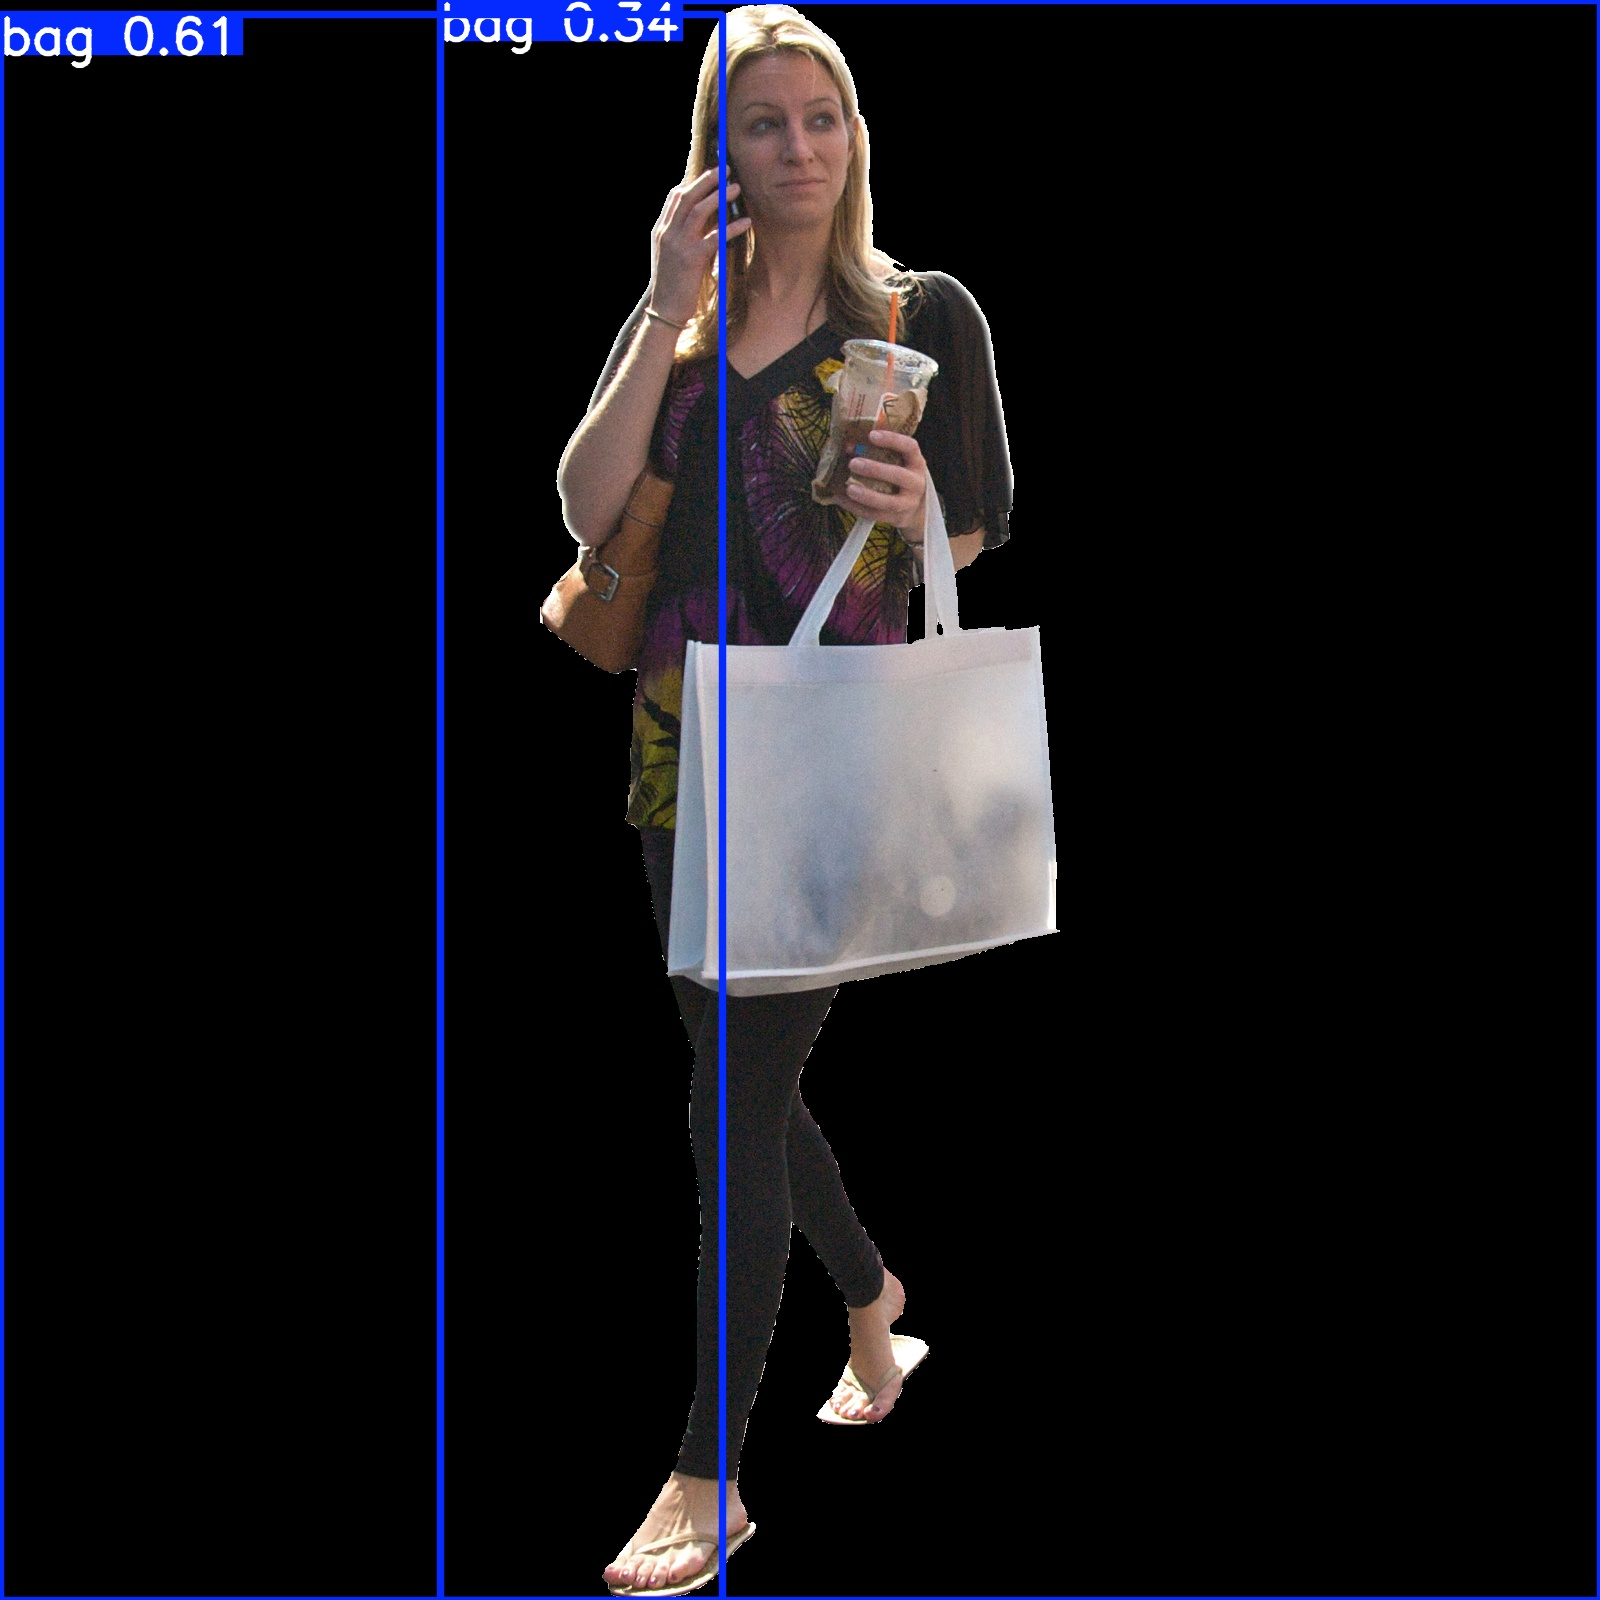

In [132]:
from ultralytics import YOLO
from IPython.display import Image, display
import os
import glob
from google.colab import files

# Правильный путь к модели
model_path = "/content/runs/detect/bag_detector-2/weights/best.pt"

print(f"Загружаем модель: {model_path}")
model = YOLO(model_path)

# Загружаем фото для тестирования
uploaded = files.upload()
test_image = list(uploaded.keys())[0]

# Предсказание
results = model.predict(
    source=test_image,
    conf=0.25,
    save=True
)

boxes = results[0].boxes

if len(boxes) > 0:
    print(f"Найдено сумок: {len(boxes)}")
    for i, box in enumerate(boxes):
        conf = box.conf[0].item()
        print(f"   Сумка {i+1}: уверенность {conf:.2%}")
else:
    print("Сумок не найдено")

# Показываем результат
result_images = glob.glob(f"{results[0].save_dir}/*")
if result_images:
    print(f"\nРезультат сохранен: {result_images[0]}")
    display(Image(filename=result_images[0]))

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

model_path = "/content/runs/detect/bag_detector/weights/best.pt"

model = YOLO(model_path)

results = model.predict(
    source=test_image,
    conf=0.25,
    save=True
)

boxes = results[0].boxes

if len(boxes) > 0:
    print("есть сумка")
else:
    print("нет сумки")


image 1/1 /content/pngwing.com (2).png: 640x640 (no detections), 11.0ms
Speed: 4.7ms preprocess, 11.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
нет сумки


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving luggage.v1i.yolov8.zip to luggage.v1i.yolov8.zip


In [ ]:
import zipfile
import os

roboflow_zip = list(uploaded.keys())[0]

os.makedirs("/content/roboflow_dataset", exist_ok=True)

with zipfile.ZipFile(roboflow_zip, "r") as zip_ref:
    zip_ref.extractall("/content/roboflow_dataset")

print("Roboflow датасет распакован")

Roboflow датасет распакован


In [ ]:
for root, dirs, files in os.walk("/content/roboflow_dataset"):
    print(root)
    print("Файлов:", len(files))
    print("-" * 40)

/content/roboflow_dataset
Файлов: 3
----------------------------------------
/content/roboflow_dataset/train
Файлов: 0
----------------------------------------
/content/roboflow_dataset/train/labels
Файлов: 2080
----------------------------------------
/content/roboflow_dataset/train/images
Файлов: 2080
----------------------------------------
/content/roboflow_dataset/valid
Файлов: 0
----------------------------------------
/content/roboflow_dataset/valid/labels
Файлов: 367
----------------------------------------
/content/roboflow_dataset/valid/images
Файлов: 367
----------------------------------------
/content/roboflow_dataset/test
Файлов: 0
----------------------------------------
/content/roboflow_dataset/test/labels
Файлов: 239
----------------------------------------
/content/roboflow_dataset/test/images
Файлов: 239
----------------------------------------


In [ ]:
import os
import shutil
from pathlib import Path

final_dataset = "/content/final_bag_dataset"

paths = [
    f"{final_dataset}/images/train",
    f"{final_dataset}/images/val",
    f"{final_dataset}/labels/train",
    f"{final_dataset}/labels/val"
]

for p in paths:
    os.makedirs(p, exist_ok=True)

print("Папки созданы")

Папки созданы


In [ ]:
def copy_dataset_part(src_img, src_lbl, dst_img, dst_lbl, prefix):
    images = list(Path(src_img).glob("*"))

    for img_path in images:
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        label_path = Path(src_lbl) / (img_path.stem + ".txt")

        if label_path.exists():
            new_img_name = prefix + "_" + img_path.name
            new_lbl_name = prefix + "_" + label_path.name

            shutil.copy(img_path, Path(dst_img) / new_img_name)
            shutil.copy(label_path, Path(dst_lbl) / new_lbl_name)

# cтарый датасет
copy_dataset_part(
    "/content/yolo_dataset/images/train",
    "/content/yolo_dataset/labels/train",
    f"{final_dataset}/images/train",
    f"{final_dataset}/labels/train",
    "old_train"
)

copy_dataset_part(
    "/content/yolo_dataset/images/val",
    "/content/yolo_dataset/labels/val",
    f"{final_dataset}/images/val",
    f"{final_dataset}/labels/val",
    "old_val"
)

print("Старый датасет добавлен")

Старый датасет добавлен


In [ ]:
#пути Roboflow
roboflow_base = "/content/roboflow_dataset"

copy_dataset_part(
    f"{roboflow_base}/train/images",
    f"{roboflow_base}/train/labels",
    f"{final_dataset}/images/train",
    f"{final_dataset}/labels/train",
    "rf_train"
)

copy_dataset_part(
    f"{roboflow_base}/valid/images",
    f"{roboflow_base}/valid/labels",
    f"{final_dataset}/images/val",
    f"{final_dataset}/labels/val",
    "rf_val"
)

print("Roboflow датасет добавлен")

Roboflow датасет добавлен


In [ ]:
yaml_text = """
path: /content/final_bag_dataset

train: images/train
val: images/val

names:
  0: bag
"""

with open("/content/final_bag_dataset/data.yaml", "w") as f:
    f.write(yaml_text)

print("Новый data.yaml создан")

Новый data.yaml создан


In [ ]:
for root, dirs, files in os.walk("/content/final_bag_dataset"):
    print(root)
    print("Файлов:", len(files))
    print("-" * 40)

/content/final_bag_dataset
Файлов: 1
----------------------------------------
/content/final_bag_dataset/labels
Файлов: 0
----------------------------------------
/content/final_bag_dataset/labels/val
Файлов: 423
----------------------------------------
/content/final_bag_dataset/labels/train
Файлов: 2224
----------------------------------------
/content/final_bag_dataset/images
Файлов: 0
----------------------------------------
/content/final_bag_dataset/images/val
Файлов: 423
----------------------------------------
/content/final_bag_dataset/images/train
Файлов: 2224
----------------------------------------


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/final_bag_dataset/data.yaml",
    epochs=100,
    imgsz=800,
    batch=8,
    patience=20,
    name="improved_bag_detector"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_bag_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=improved_bag_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fcb78f4f830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Saving images.jpg to images (5).jpg

image 1/1 /content/images (5).jpg: 800x608 1 bag, 20.1ms
Speed: 2.7ms preprocess, 20.1ms inference, 1.3ms postprocess per image at shape (1, 3, 800, 608)
Results saved to /content/runs/detect/predict-75
есть сумка


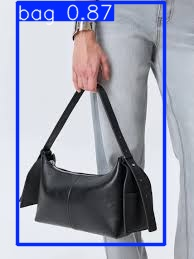

In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import glob

model = YOLO("/content/runs/detect/improved_bag_detector/weights/best.pt")

uploaded = files.upload()
test_image = list(uploaded.keys())[0]

results = model.predict(
    source=test_image,
    conf=0.4,
    iou=0.5,
    save=True
)

if len(results[0].boxes) > 0:
    print("есть сумка")
else:
    print("нет сумки")

result_images = glob.glob(f"{results[0].save_dir}/*")
display(Image(filename=result_images[0]))

In [130]:
import shutil
import os

os.makedirs("/content/drive/MyDrive/bag_project", exist_ok=True)

shutil.copy(
    "/content/runs/detect/bag_detector/weights/best.pt",
    "/content/drive/MyDrive/bag_project/bag_detector_best.pt"
)

print("Модель сохранена на Google Drive")

Модель сохранена на Google Drive


In [131]:
model = YOLO("/content/drive/MyDrive/bag_project/bag_detector_best.pt")

In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
import os

model_path = "/content/drive/MyDrive/bag_project/bag_detector_best.pt"

print(os.path.exists(model_path))

True


Saving а (12).jpg to а (12) (2).jpg

image 1/1 /content/а (12) (2).jpg: 640x448 2 bags, 45.0ms
Speed: 2.7ms preprocess, 45.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict-77
Найдено сумок: 2
Сумка 1: уверенность 96.15%
Сумка 2: уверенность 57.32%


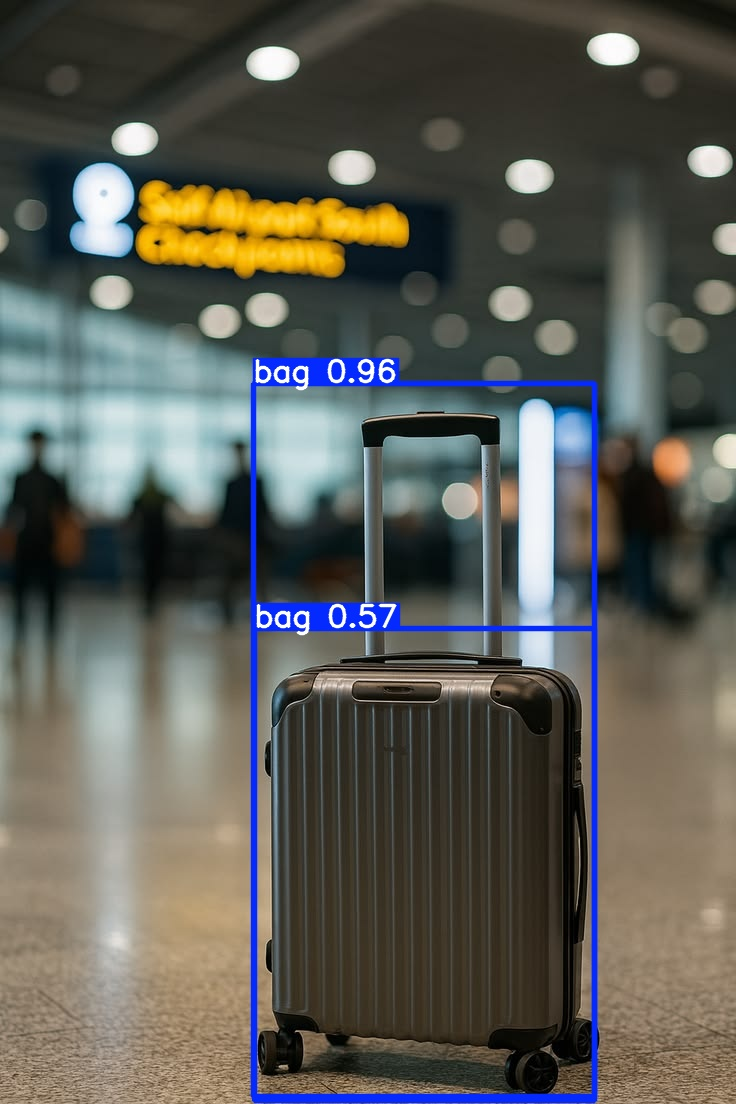

In [129]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import glob

model_path = "/content/drive/MyDrive/bag_project/bag_detector_best.pt"

model = YOLO(model_path)

uploaded = files.upload()

test_image = list(uploaded.keys())[0]

results = model.predict(
    source=test_image,
    conf=0.25,
    save=True
)

#найденные объекты проверка
boxes = results[0].boxes

if len(boxes) > 0:
    print(f"Найдено сумок: {len(boxes)}")

    for i, box in enumerate(boxes):
        conf = box.conf[0].item()
        print(f"Сумка {i+1}: уверенность {conf:.2%}")

else:
    print("Сумок не найдено")

#изображение
result_images = glob.glob(f"{results[0].save_dir}/*")

display(Image(filename=result_images[0]))